# A/B Testing Fundamentals: A Practical Guide for Data Analysis

**Published:** October 22, 2025 
**Tags:** Statistics, Python
**Excerpt:** This comprehensive guide walks you through sampling theory basics and hypothesis testing (A/B testing), featuring detailed examples comparing means and proportions between groups, along with intuitive visualizations to make the concepts easy to understand.
**Slug:** a-b-testing-fundamentals
**Cover Image Path:** blog_images/blog_10_cover.png

---
# A/B Testing Fundamentals: A Practical Guide for Data Analysis

## Introduction

In today’s data-driven world, making decisions based on **evidence** rather than intuition is essential. **A/B testing** provides a scientific framework to compare different versions of a product, webpage, or feature to determine which performs better. This notebook demystifies the **statistical foundations of A/B testing** and provides practical guidance for implementation in Python.

We’ll start by exploring fundamental statistical concepts—**sampling, distributions, and uncertainty**—before moving into **hypothesis testing**. Instead of presenting abstract formulas, we’ll build intuition through **visualization and simulation**. You’ll learn how to:

* Estimate **population parameters** from samples
* Quantify **uncertainty** in your estimates
* Compare **means and proportions** between groups
* Make statistically sound decisions using **confidence intervals** and **p-values**

Whether you’re a **product manager** validating design changes, a **marketer** optimizing conversion rates, or a **data scientist** establishing testing frameworks, this guide will equip you to **interpret A/B tests with confidence**.

Let’s begin by understanding **why we sample data** instead of measuring entire populations.


## Revisiting Statistics: Understanding Population Parameters

### Why We Sample Instead of Measuring Everyone

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tools
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Notebook settings
import warnings

warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output
# --- VISUALIZATION SETUP ---
# Set consistent styling for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = "retina"
%load_ext jupyter_black
# Color palettes for consistency across visualizations
high_contrast_colors = [
    "#003f5c",
    "#ff6e54",
    "#f9f871",
    "#2db88b",
    "#955196",
]  # For primary visuals
milder_colors = [
    "#00798c",
    "#d1495b",
    "#edae49",
    "#52a369",
    "#756ab2",
]  # For secondary visuals

Suppose we are tasked with finding the **average weight of people** in a country named **"No Ones Land"**. The country has a population of **5 million people**, so weighing everyone is impractical.  

Instead, we can **sample people from different locations** across the country to estimate the population mean. For example, we visit **1,000 locations**, and in each location, we ask **500 people** for their weight. These samples are stored in `df_samples` and you can see head of that dataframe below.  

*(Note: This is synthetic data. I generated it using a normally distributed population and randomly selected 1,000 samples of 500 points each. The synthetic population is in `df_population`.)*

In [2]:
np.random.seed(42)  # For reproducibility
population_size = 5_000_000
# Generate a synthetic population of weights (in kg) following a normal distribution
weights = np.random.normal(loc=75, scale=10, size=population_size)
df_population = pd.DataFrame(weights, columns=["weight"])
df_population["people_id"] = [f"person_{i+1}" for i in range(population_size)]
print(f"Shape of Population DataFrame: {df_population.shape}")
df_population.head()

Shape of Population DataFrame: (5000000, 2)


,weight,people_id
0,79.967142,person_1
1,73.617357,person_2
2,81.476885,person_3
3,90.230299,person_4
4,72.658466,person_5


In [3]:
np.random.seed(42)  # For reproducibility
samples_ = np.random.normal(loc=75, scale=10, size=[1000, 500])
# make it a DataFrame with column sample_id and weight
df_samples = pd.DataFrame(samples_.T)
df_samples = df_samples.melt(var_name="sample_id", value_name="weight")
df_samples["person_id"] = "person_" + (
    df_samples.groupby("sample_id").cumcount() + 1
).astype(str)
df_samples["sample_id"] = "sample_" + df_samples["sample_id"].astype(str)
df_samples = df_samples[["sample_id", "person_id", "weight"]]
print(f"Shape of Samples DataFrame: {df_samples.shape}")
df_samples.head()

Shape of Samples DataFrame: (500000, 3)


,sample_id,person_id,weight
0,sample_0,person_1,79.967142
1,sample_0,person_2,73.617357
2,sample_0,person_3,81.476885
3,sample_0,person_4,90.230299
4,sample_0,person_5,72.658466


## Examining Sample Distributions

Let's explore how our samples are distributed. The histogram below shows that while each sample has its own unique distribution, they share similar patterns because they all come from the same underlying population.

Notice the x-axis scale — most weights fall between **50 and 100 kg** with the peak around **75kg**. This central tendency is captured by the **mean**, while the spread of individual weights within each sample is quantified by the **standard deviation**.

These key statistics can be easily calculated in Python using the `mean()` and `std()` methods, giving us a mathematical summary of each sample's characteristics.

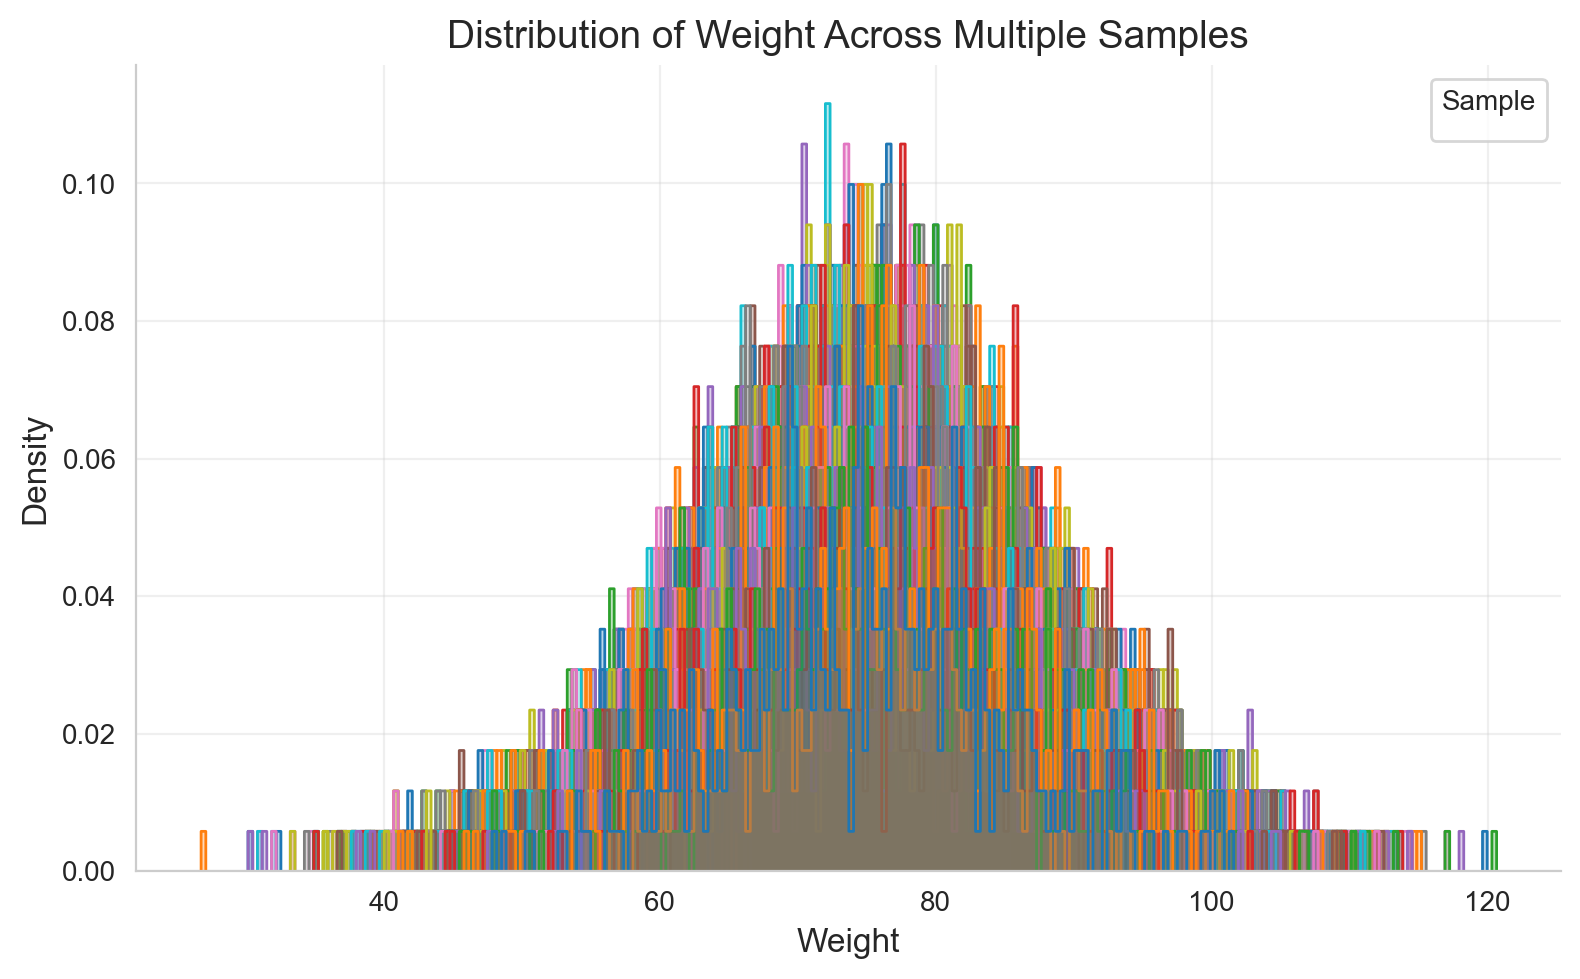

In [4]:
# Plot the distribution of exam scores for a subset of samples (showing all 1000 would be too cluttered)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_samples[
        df_samples["sample_id"].isin([f"sample_{i+1}" for i in range(1000)])
    ],
    x="weight",
    hue="sample_id",
    element="step",
    stat="density",
    common_norm=False,
    palette=sns.color_palette("tab10", n_colors=10),
    alpha=0.3,
    legend=True,
)
plt.title("Distribution of Weight Across Multiple Samples", fontsize=14)
plt.xlabel("Weight", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title="Sample", fontsize=10, title_fontsize=10, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

### Sampling Distribution: The Power of Sample Means

Now, let's shift our focus from individual data points to **sample means**. Instead of examining individual weights, we'll analyze the **average weight calculated from each sample**.

Below is a head of our sample means dataframe, where each row represents the average weight from one of our 1,000 samples:

In [5]:
df_samples_mean = df_samples.groupby("sample_id").weight.mean().reset_index()
df_samples_mean.head()

,sample_id,weight
0,sample_0,75.068380
1,sample_1,75.318261
2,sample_10,74.671407
3,sample_100,74.977417
4,sample_101,74.991249


Plotting a histogram of these sample means, we notice the **distribution is narrower** than the original weight distributions. While individual weights lie between 50 and 100 kg, sample means are mostly between **74 and 76 kg**.

Taking the **mean of the sample means** approximates the **population mean**, which aligns closely with the actual mean of `df_population`.  

We can also calculate a **95% confidence interval (CI)** for the sample means, which represents the range where we expect **95% of sample means to lie**:

$$
\text{CI}_{95\%} = \bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}
$$

This interval gives us a sense of **uncertainty** around the estimated population mean.

Plotting a histogram of these sample means, we observe that the **distribution is much narrower** than the original weight distribution. While individual weights range from 50 to 100 kg, the sample means mostly fall between **74 and 76 kg**.

If we take one more average — the **mean of these sample means** — we get an approximation of the **population mean**, which closely matches the actual mean of our original dataset `df_population`.

Additionally, we can calculate the **standard deviation of the sample means**, which shows how much the sample means tend to vary from the true population mean. *(Teaser: remember this number—we’ll come back to it later.)*

We can also determine the range where about **95% of the sample means** are expected to fall — this is known as the **confidence interval**.



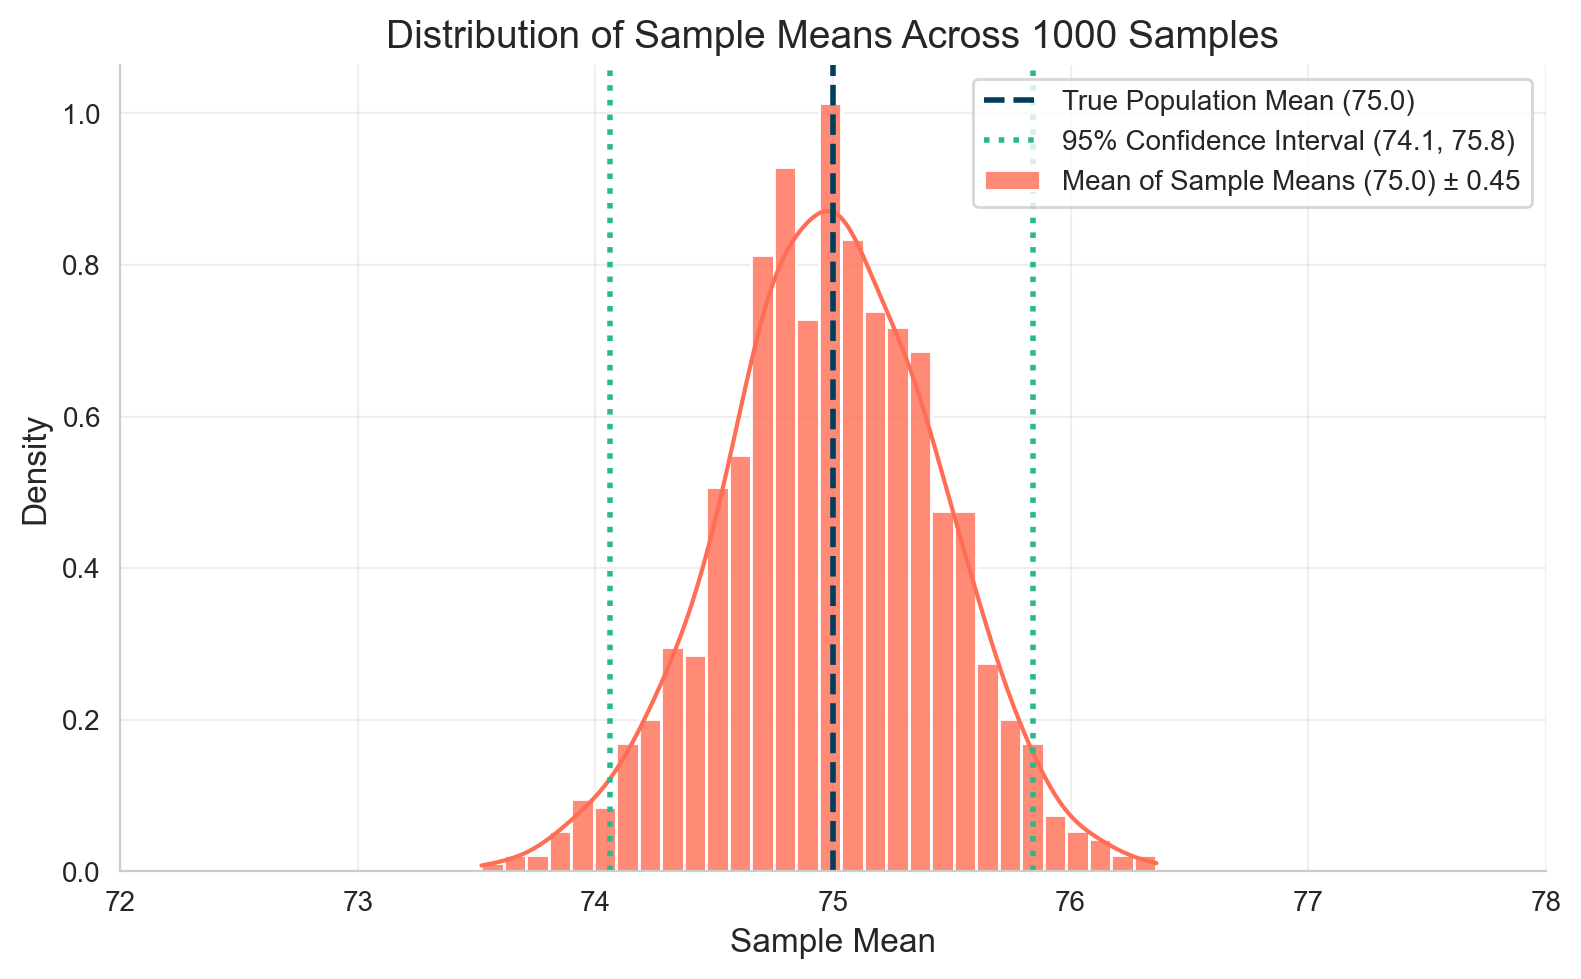

In [6]:
mean_of_sample_means = df_samples_mean["weight"].mean()
std_of_sample_means = df_samples_mean["weight"].std()
true_population_mean = df_population["weight"].mean()
plt.figure(figsize=(8, 5))

# Plot histogram with KDE of sample means
sns.histplot(
    data=df_samples_mean,
    x="weight",
    bins=30,
    kde=True,
    color=high_contrast_colors[1],
    stat="density",
    alpha=0.8,
    edgecolor="white",
    label=f"Mean of Sample Means ({mean_of_sample_means:.1f}) ± {std_of_sample_means:.2f}",
)

# Add vertical line for the population mean
plt.axvline(
    x=true_population_mean,
    color=high_contrast_colors[0],
    linestyle="--",
    linewidth=2,
    label=f"True Population Mean ({true_population_mean:.1f})",
)
# 95% confidence interval using empirical percentiles (2.5% and 97.5%)
ci_95_lower = df_samples_mean["weight"].quantile(0.025).round(2)
ci_95_upper = df_samples_mean["weight"].quantile(0.975).round(2)
plt.axvline(
    x=ci_95_lower,
    color=high_contrast_colors[3],
    linestyle=":",
    linewidth=2,
    label=f"95% Confidence Interval ({ci_95_lower:.1f}, {ci_95_upper:.1f})",
)
plt.axvline(
    x=ci_95_upper,
    color=high_contrast_colors[3],
    linestyle=":",
    linewidth=2,
)
# Add title and labels
plt.title("Distribution of Sample Means Across 1000 Samples", fontsize=14)
plt.xlabel("Sample Mean", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.xlim(72, 78)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### Single Sample vs. Thousands of Samples: The Magic of Standard Error

Collecting thousands of samples is rarely practical in real life. To overcome this, statisticians developed a way to estimate population parameters **from just one sample**. Instead of repeating the experiment thousands of times, we can do it once and infer the population characteristics.

Let's randomly pick a **single sample** from our `df_samples` dataframe and try to estimate the previously calculated values — the **mean of sample means**, the **standard deviation of sample means**, and the **confidence interval around the mean of sample means**.

We now introduce a new term: the **standard error (SE)** — a measure of the statistical accuracy of an estimate. It is calculated by dividing the standard deviation of the single sample by the square root of its size:

$$
SE = \frac{s}{\sqrt{n}}
$$

Using the standard error, we can compute the **95% confidence interval** for the estimated mean:

$$
\text{CI}_{95\%} = \bar{x} \pm 1.96 \cdot SE
$$

> Note: The factor 1.96 comes from the 68-95-99.7 rule of the standard normal distribution, where approximately 95% of data points lie within 1.96 standard deviations from the mean.

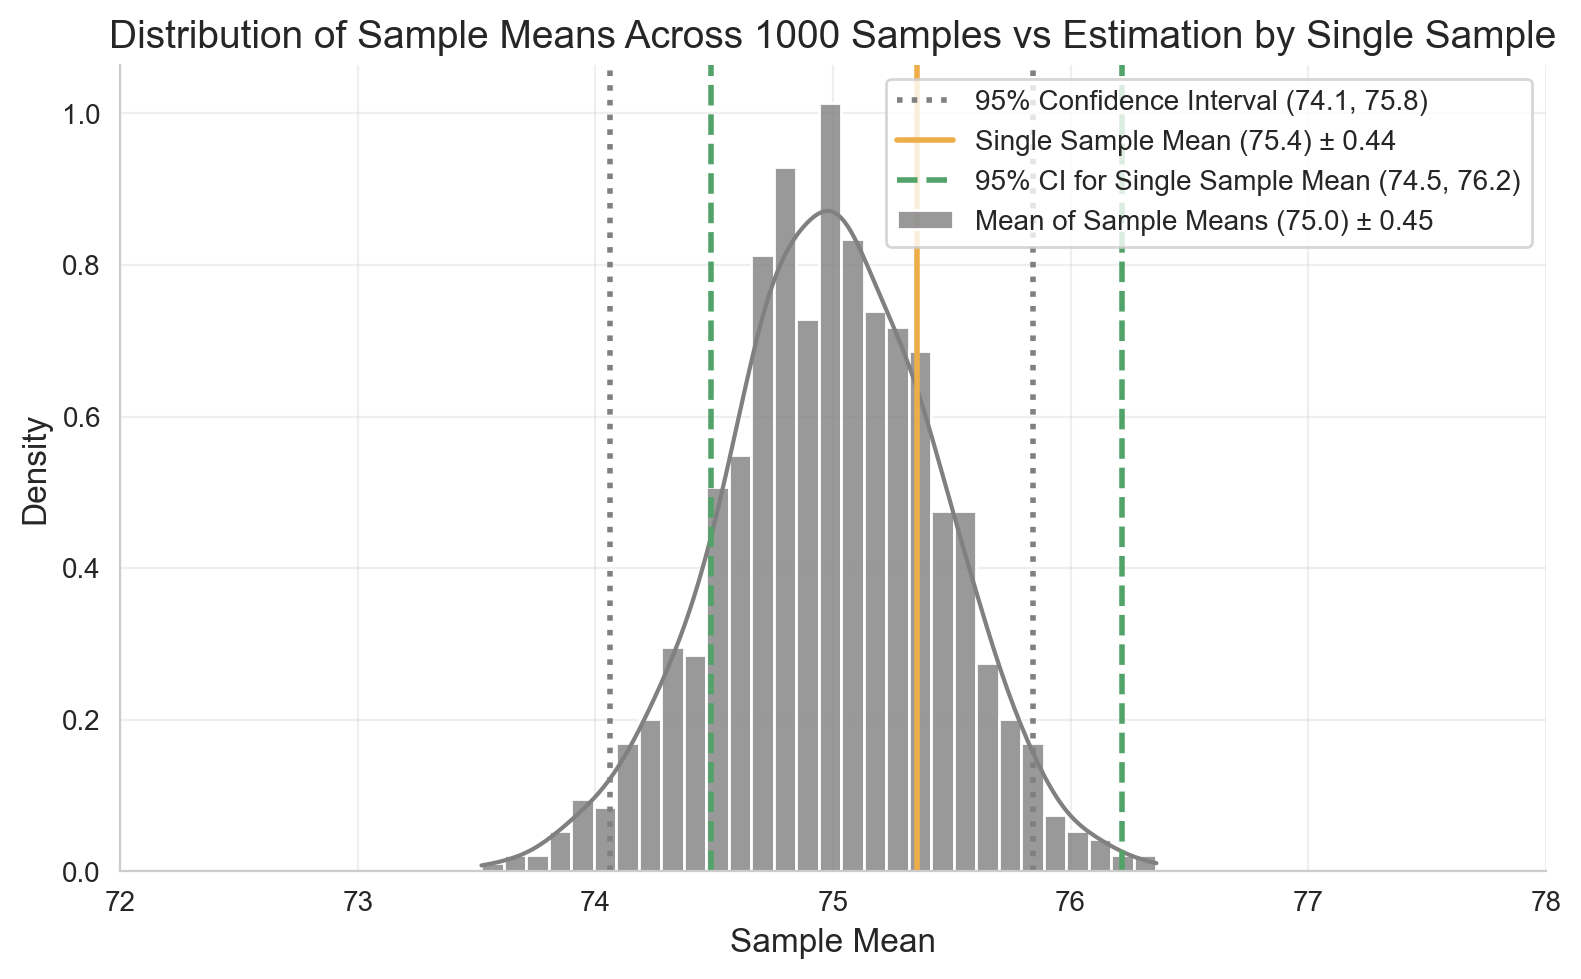

In [7]:
random_sample_id = (
    df_samples["sample_id"].drop_duplicates().sample(n=1, random_state=45)
)
df_single_sample = df_samples[df_samples["sample_id"] == random_sample_id.values[0]]
single_sample_mean = df_single_sample["weight"].mean()
single_sample_std = df_single_sample["weight"].std()
single_sample_data_points = df_single_sample["weight"].count()
standard_error_single_sample = single_sample_std / np.sqrt(single_sample_data_points)
single_sample_ci_95_lower = single_sample_mean - 1.96 * standard_error_single_sample
single_sample_ci_95_upper = single_sample_mean + 1.96 * standard_error_single_sample
plt.figure(figsize=(8, 5))
# Plot histogram with KDE of sample means
sns.histplot(
    data=df_samples_mean,
    x="weight",
    bins=30,
    kde=True,
    color="gray",
    stat="density",
    alpha=0.8,
    edgecolor="white",
    label=f"Mean of Sample Means ({mean_of_sample_means:.1f}) ± {std_of_sample_means:.2f}",
)
# 95% confidence interval using empirical percentiles (2.5% and 97.5%)
ci_95_lower = df_samples_mean["weight"].quantile(0.025).round(2)
ci_95_upper = df_samples_mean["weight"].quantile(0.975).round(2)
plt.axvline(
    x=ci_95_lower,
    color="gray",
    linestyle=":",
    linewidth=2,
    label=f"95% Confidence Interval ({ci_95_lower:.1f}, {ci_95_upper:.1f})",
)
plt.axvline(
    x=ci_95_upper,
    color="gray",
    linestyle=":",
    linewidth=2,
)
# Add vertical line for the single sample mean
plt.axvline(
    x=single_sample_mean,
    color=milder_colors[2],
    linestyle="-",
    linewidth=2,
    label=f"Single Sample Mean ({single_sample_mean:.1f}) ± {standard_error_single_sample:.2f}",
)
# 95% confidence interval for the single sample mean
plt.axvline(
    x=single_sample_ci_95_lower,
    color=milder_colors[3],
    linestyle="--",
    linewidth=2,
    label=f"95% CI for Single Sample Mean ({single_sample_ci_95_lower:.1f}, {single_sample_ci_95_upper:.1f})",
)
plt.axvline(
    x=single_sample_ci_95_upper,
    color=milder_colors[3],
    linestyle="--",
    linewidth=2,
)
# Add title and labels
plt.title(
    "Distribution of Sample Means Across 1000 Samples vs Estimation by Single Sample",
    fontsize=14,
)
plt.xlabel("Sample Mean", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.xlim(72, 78)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Did you notice that the **standard error** we calculated here ($SE = 0.44$) is very close to the **standard deviation of sample means** ($s = 0.45$) we calculated previously?

Additionally, the **uncertainty** we computed around our single sample mean guarantees that, **95% of the time, the true population mean will fall within this range**. So, even though our single sample mean may not exactly equal the population mean, the **standard error** and **confidence interval** together give us a complete picture of the estimate’s reliability.

### Sample Size Matters

Sample size is crucial because it appears in the **denominator of the standard error** formula. Small samples may not represent the population well, leading to higher variability.

Increasing the sample size ($n$) **reduces the standard error** and **narrows the confidence interval**, improving the accuracy of our estimate. The simulation below shows how the mean, standard error, and confidence interval change with different sample sizes.


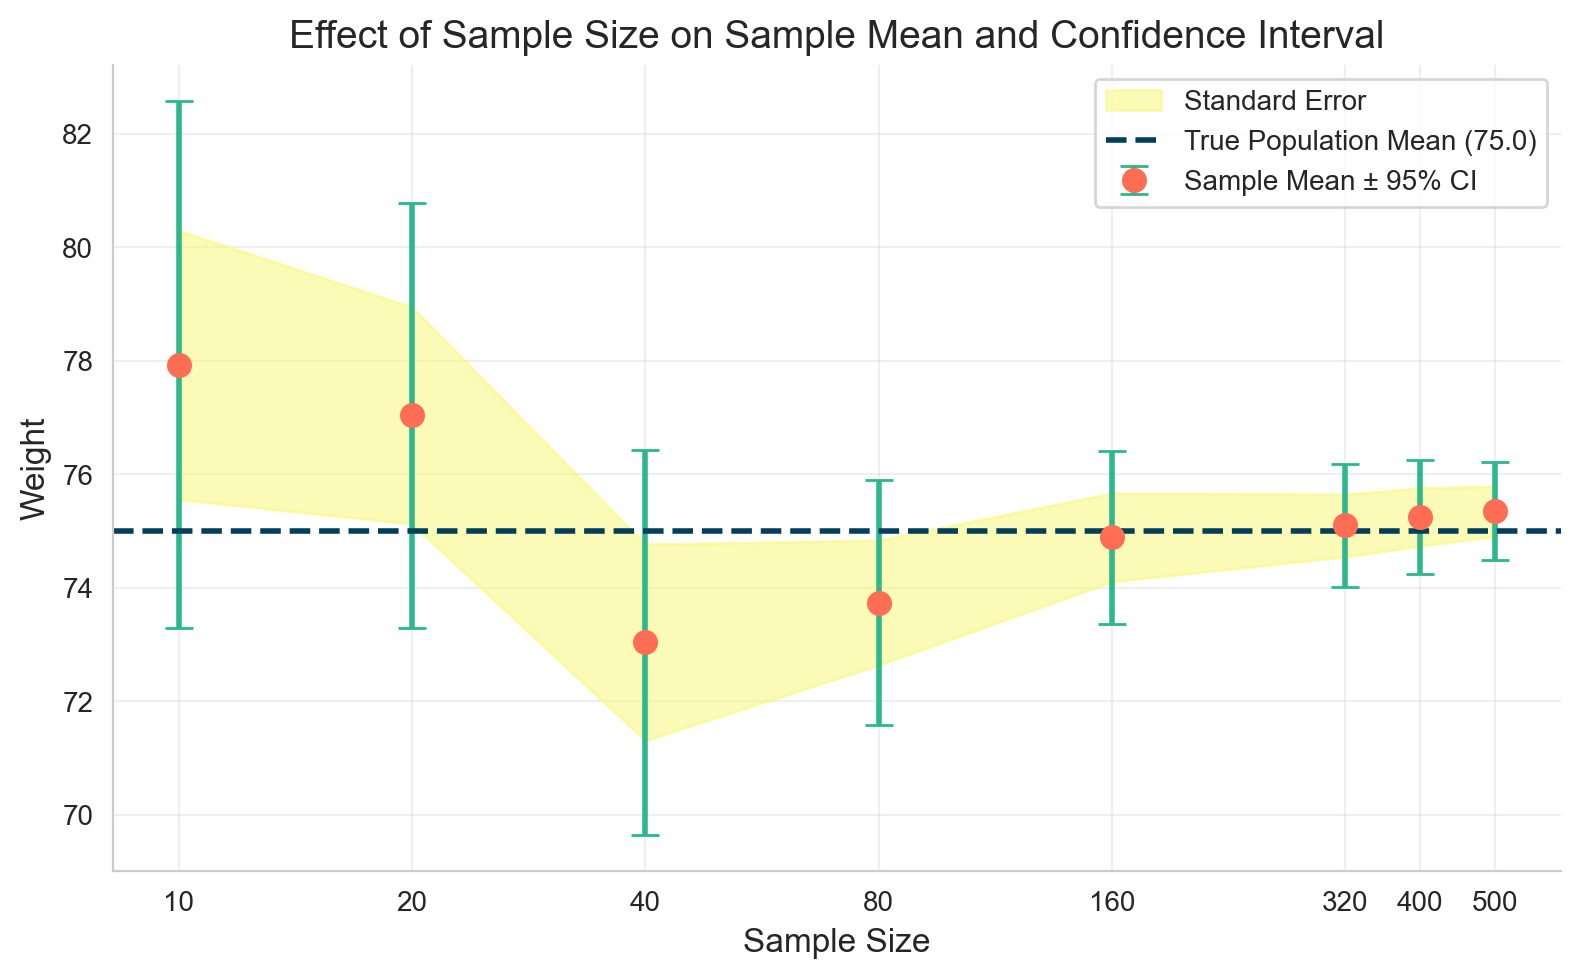

In [8]:
df_stats_by_sample_size = pd.DataFrame(
    columns=[
        "sample_size",
        "sample_mean",
        "sample_std",
        "sample_se",
        "ci_95_lower",
        "ci_95_upper",
    ]
)
sizes = [10, 20, 40, 80, 160, 320, 400, 500]
for sample_size in sizes:
    data = df_single_sample["weight"].sample(n=sample_size, random_state=1)
    sample_mean = data.mean()
    sample_std = data.std()
    sample_se = sample_std / np.sqrt(sample_size)
    ci_95_lower = sample_mean - 1.96 * sample_se
    ci_95_upper = sample_mean + 1.96 * sample_se
    df_stats_by_sample_size = pd.concat(
        [
            df_stats_by_sample_size,
            pd.DataFrame(
                {
                    "sample_size": [sample_size],
                    "sample_mean": [sample_mean],
                    "sample_std": [sample_std],
                    "sample_se": [sample_se],
                    "ci_95_lower": [ci_95_lower],
                    "ci_95_upper": [ci_95_upper],
                }
            ),
        ],
        ignore_index=True,
    )
df_stats_by_sample_size = df_stats_by_sample_size.round(2)
# plot mean and 95% CI for different sample sizes and also plot se for different sample sizes
# Ensure sample_size is numeric for plotting
df_stats_by_sample_size["sample_size"] = df_stats_by_sample_size["sample_size"].astype(
    int
)
plt.figure(figsize=(8, 5))
# Plot sample means with error bars for 95% CI
plt.errorbar(
    x=df_stats_by_sample_size["sample_size"],
    y=df_stats_by_sample_size["sample_mean"],
    yerr=1.96 * df_stats_by_sample_size["sample_se"],
    fmt="o",
    markersize=8,
    color=high_contrast_colors[1],
    ecolor=high_contrast_colors[3],
    elinewidth=2,
    capsize=5,
    label="Sample Mean ± 95% CI",
)
# Plot standard error as shaded area
plt.fill_between(
    x=df_stats_by_sample_size["sample_size"],
    y1=df_stats_by_sample_size["sample_mean"] - df_stats_by_sample_size["sample_se"],
    y2=df_stats_by_sample_size["sample_mean"] + df_stats_by_sample_size["sample_se"],
    color=high_contrast_colors[2],
    alpha=0.5,
    label="Standard Error",
)
# Add horizontal line for true population mean
plt.axhline(
    y=true_population_mean,
    color=high_contrast_colors[0],
    linestyle="--",
    linewidth=2,
    label=f"True Population Mean ({true_population_mean:.1f})",
)
# Add titles and labels
plt.title("Effect of Sample Size on Sample Mean and Confidence Interval", fontsize=14)
plt.xlabel("Sample Size", fontsize=12)
plt.ylabel("Weight", fontsize=12)
plt.xscale("log")
plt.xticks(sizes, sizes)
# plt.ylim(66, 84)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Did you notice how the **sample mean approaches the true population mean** as the sample size increases? At the same time, the **confidence interval around our estimate gets narrower**, thanks to the **Central Limit Theorem**.


## A/B Testing Basics: Comparing Two Groups Statistically

Now that we’ve refreshed our understanding of estimating population parameters from a single sample and accounting for uncertainty, we can move on to **A/B testing**. Let’s start with the theory and then do a practical example.

### What is A/B Testing?

**A/B testing** is a method to compare **two groups** to see if there’s a statistically significant difference between them.

* **Null hypothesis ($H_0$)**: There is **no difference** between the groups.
* **Alternative hypothesis ($H_1$)**: The groups **differ**.

Depending on the type of data:

* For **continuous data** (e.g., weight, acquisition cost), we compare **means**.
* For **binary data** (e.g., conversion rates, success rate), we compare **proportions**.

**General process:**

1. Calculate group statistics with uncertainty (mean/proportion, SE)
2. Assess whether the observed differences are **statistically significant**


### Common Approaches in A/B Testing

Here are two approaches to compare two groups. The first is less commonly used directly, while the second is the standard method for A/B testing:

1. **Confidence Interval Overlap**
   Compute the means (or proportions) and SEs for each group, then build confidence intervals.

   * If the **intervals do not overlap**, reject $H_0$ — the groups differ.

2. **Standardized Difference (z-score / t-statistic)**
   This is the **de facto standard** for A/B testing.

   Steps:

   * Compute the **test statistic** ($\text{t-statistic}$) using the sample means and variances. The formula differs slightly for means versus proportions (details follow in the corresponding sections).
   * Check where this ($\text{t-statistic}$) falls in a **standard normal distribution** ($\mu = 0$, $\sigma = 1$); 95% of values lie within ±1.96).
   * Compute the **p-value** — the probability of observing a result as extreme as the ($\text{t-statistic}$) under $H_0$. Reject $H_0$ if $p < \alpha$ (commonly 0.05).


## Practical Example: Comparing Group Means

Imagine a friend from a country called **“Wonderstan”** claims their population is heavier than **No Ones Land**. Since we already know how to estimate population parameters from a single sample, we can test this claim without weighing the entire population:
* Sample **550 people from Wonderstan**
* Use our **500-person sample from No Ones Land**


In [9]:
df_no_ones_land_single_sample = (
    df_single_sample.reset_index(drop=True).copy().drop(columns=["sample_id"])
)
df_no_ones_land_single_sample["country"] = "No Ones Land"
df_no_ones_land_single_sample.head()
np.random.seed(42)  # For reproducibility
samples_ = np.random.normal(loc=78, scale=13, size=250)
df_wonderstan_single_sample = pd.DataFrame(samples_, columns=["weight"])
df_wonderstan_single_sample["person_id"] = [f"person_{i+1}" for i in range(250)]
df_wonderstan_single_sample["country"] = "Wonderstan"
df_wonderstan_single_sample.head()
df_ab_test = pd.concat(
    [df_no_ones_land_single_sample, df_wonderstan_single_sample], ignore_index=True
)
df_ab_test.head()

,person_id,weight,country
0,person_1,70.679798,No Ones Land
1,person_2,71.778589,No Ones Land
2,person_3,85.799607,No Ones Land
3,person_4,84.839126,No Ones Land
4,person_5,65.453063,No Ones Land


First, let’s visualize the data. Plot histograms for each sample. The distributions overlap quite a bit, but the peak for **Wonderstan** is slightly to the right.

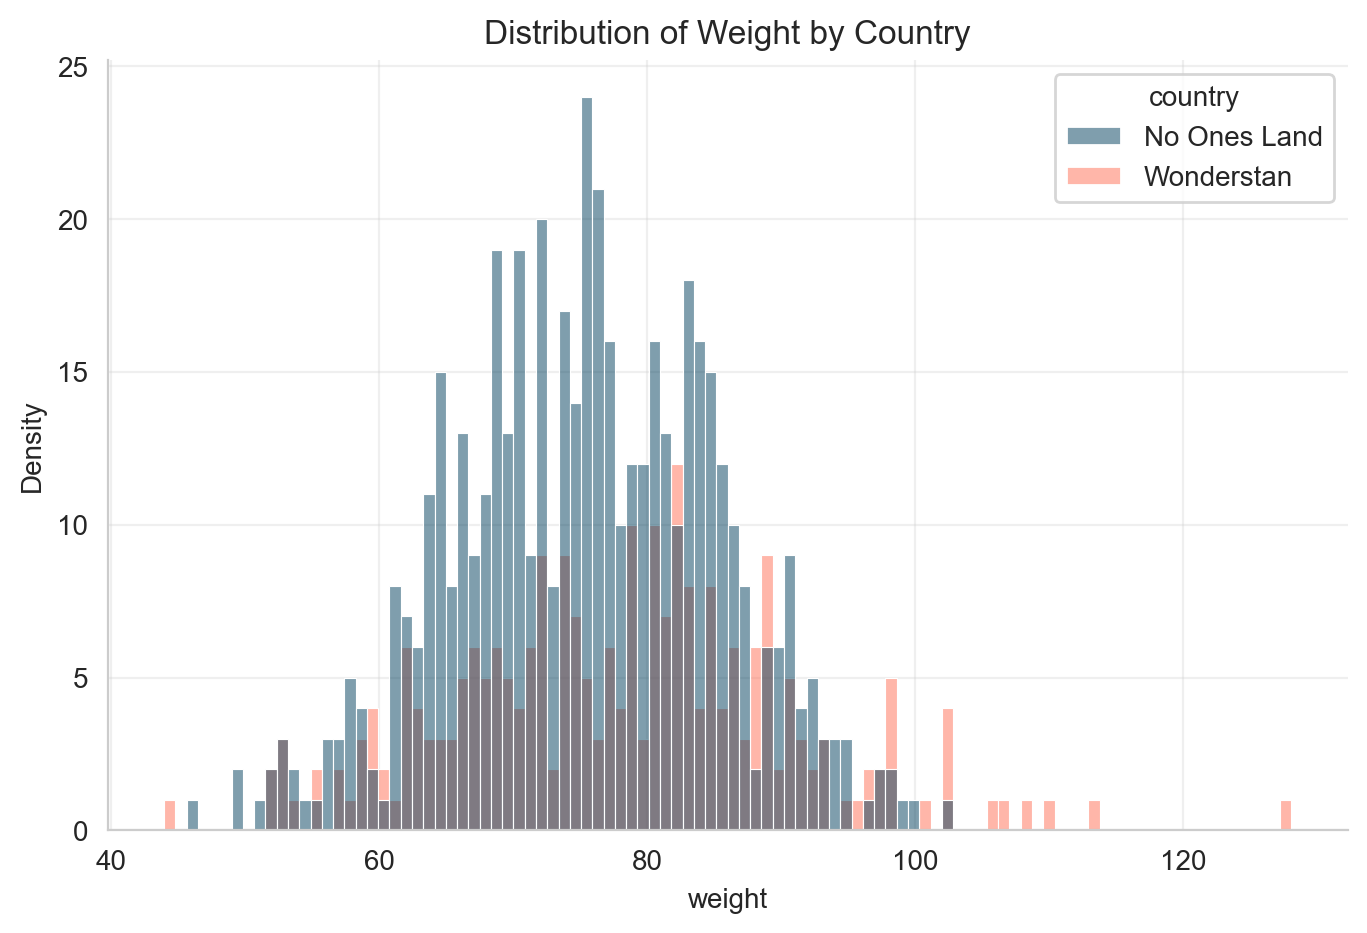

In [10]:
# plot kdeplot using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_ab_test,
    x="weight",
    hue="country",
    fill=True,
    bins=100,
    alpha=0.5,
    palette=high_contrast_colors,
)
plt.title("Distribution of Weight by Country")
plt.xlabel("weight")
plt.ylabel("Density")
plt.grid(alpha=0.3)
sns.despine()
plt.show()

Next, we calculate the **means** for each sample along with the **uncertainty** (standard deviation → standard error → confidence interval). Then, we check whether the **confidence intervals overlap** to see if the difference is statistically significant.

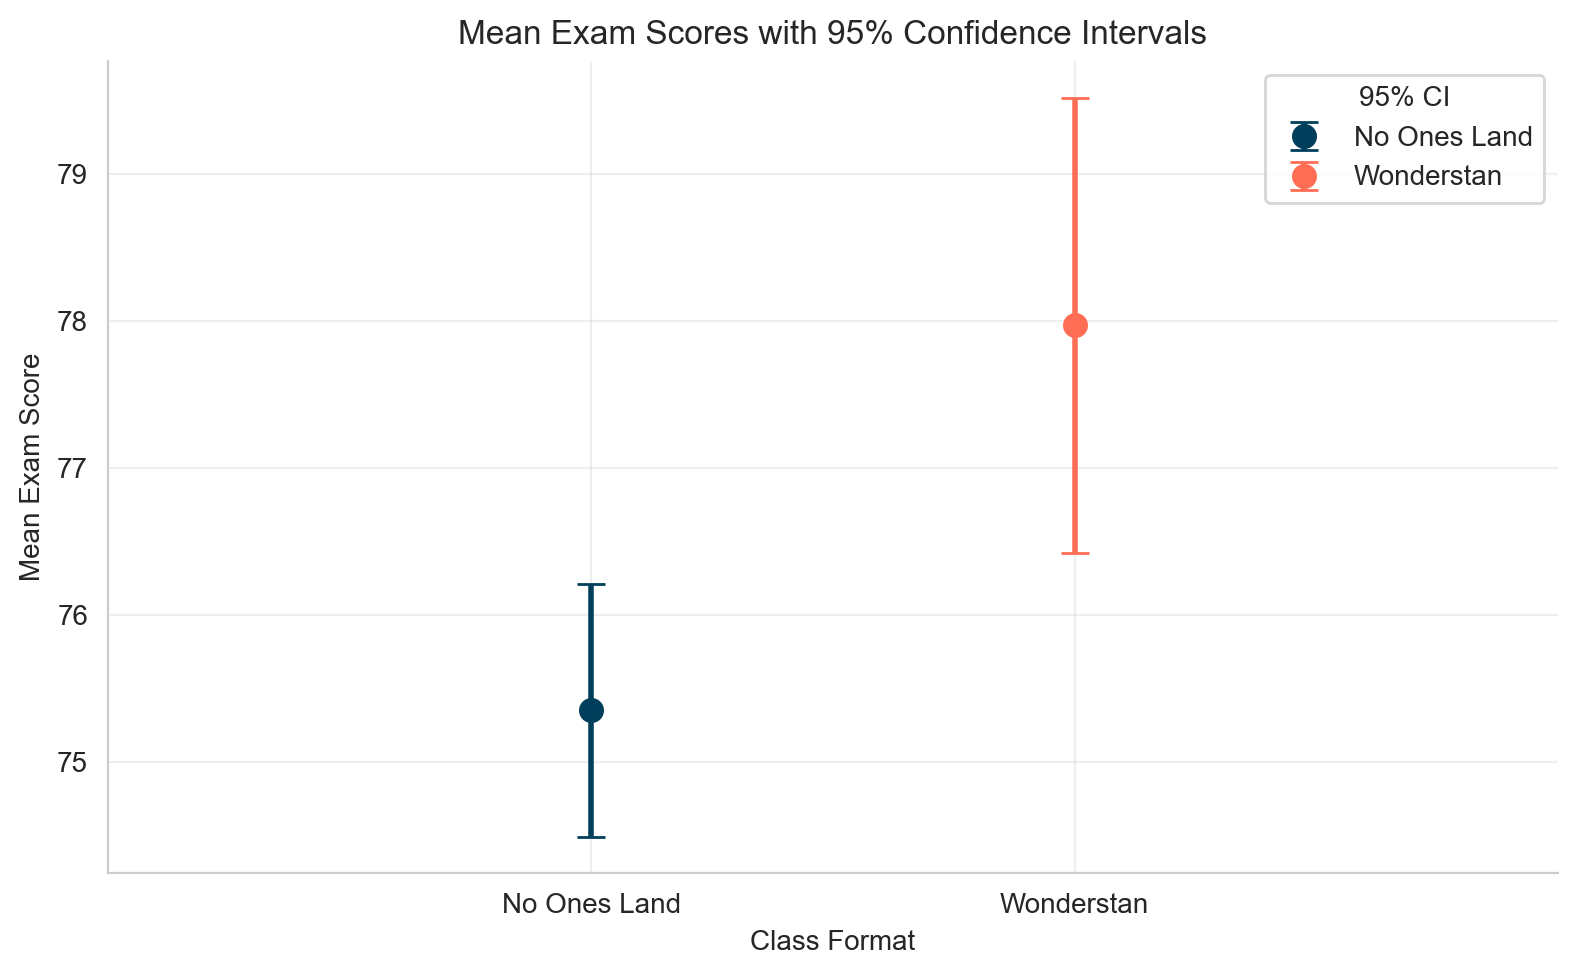

In [11]:
df_summary_stats = (
    df_ab_test.groupby("country").weight.agg(["mean", "std", "count", "sem"]).round(2)
)
df_summary_stats["ci_95_lower"] = (
    df_summary_stats["mean"] - 1.96 * df_summary_stats["sem"]
)
df_summary_stats["ci_95_upper"] = (
    df_summary_stats["mean"] + 1.96 * df_summary_stats["sem"]
)
df_summary_stats = df_summary_stats.reset_index().round(2)
fig = plt.figure(figsize=(8, 5))
for i, group in enumerate(df_summary_stats["country"]):
    plt.errorbar(
        group,
        df_summary_stats["mean"].iloc[i],
        yerr=np.array(
            [
                df_summary_stats["mean"].iloc[i]
                - df_summary_stats["ci_95_lower"].iloc[i],
                df_summary_stats["ci_95_upper"].iloc[i]
                - df_summary_stats["mean"].iloc[i],
            ]
        ).reshape(2, 1),
        fmt="o",
        linewidth=2,
        markersize=8,
        color=high_contrast_colors[i % len(high_contrast_colors)],
        capsize=5,
        label=group,
    )

# Customize plot appearance
plt.title("Mean Exam Scores with 95% Confidence Intervals")
plt.xlabel("Class Format")
plt.ylabel("Mean Exam Score")
plt.grid(alpha=0.3)
plt.legend(title="95% CI")
# plt.ylim(70, 81)
plt.xlim(-1, 2)
sns.despine()
plt.tight_layout()
plt.show()

Well, as you can see, the **95% confidence intervals do not overlap**. We can already conclude that the weights of these two countries are different — on average, people from **Wonderstan** are heavier.

However, let’s compare the means using the **p-value method** as well. For this we will follow these steps:

1. **Formulate Hypotheses**

   * (H_0: \mu_1 - \mu_2 = 0) — no difference between means
   * (H_1: \mu_1 - \mu_2 \neq 0) — means differ

2. **Calculate Test Statistics**

   * Difference in means:

$$
\Delta = \bar{x}_1 - \bar{x}_2
$$

* Standard error of the difference:

$$
SE_\Delta = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}
$$

* Test statistic:

$$
\text{t-statistic} = \frac{\Delta}{SE_\Delta}
$$

3. **Decision**

   * Compute the **p-value** — the probability of observing a $\text{t-statistic}$ this extreme under $H_0$.
   * Reject (H_0) if (p < 0.05).


In [12]:
wonderstan_data_points = df_ab_test[df_ab_test["country"] == "Wonderstan"][
    "weight"
].values
no_ones_land_data_points = df_ab_test[df_ab_test["country"] == "No Ones Land"][
    "weight"
].values
mean_difference = wonderstan_data_points.mean() - no_ones_land_data_points.mean()
print(
    f"Mean Difference (Mean of Wonderstan - Mean of No Ones Land): {mean_difference:.2f}"
)
standard_error_of_difference = np.sqrt(
    np.var(wonderstan_data_points) / len(wonderstan_data_points)
    + np.var(no_ones_land_data_points) / len(no_ones_land_data_points)
)
print(f"Standard Error of the Difference: {standard_error_of_difference:.2f}")
t_statistic = mean_difference / standard_error_of_difference
print(f"T-Statistic: {t_statistic:.2f}")

Mean Difference (Mean of Wonderstan - Mean of No Ones Land): 2.62
Standard Error of the Difference: 0.91
T-Statistic: 2.88


We found that the **t-statistic** is $\text{t-statistic} = 2.88$. Now, we can plot a **standard normal distribution** and see where this value falls. As shown in the chart below, the t-statistic lies **outside the 95% range**. Therefore, we **reject $H_0$** — there is a statistically significant difference between the weights of the two countries.

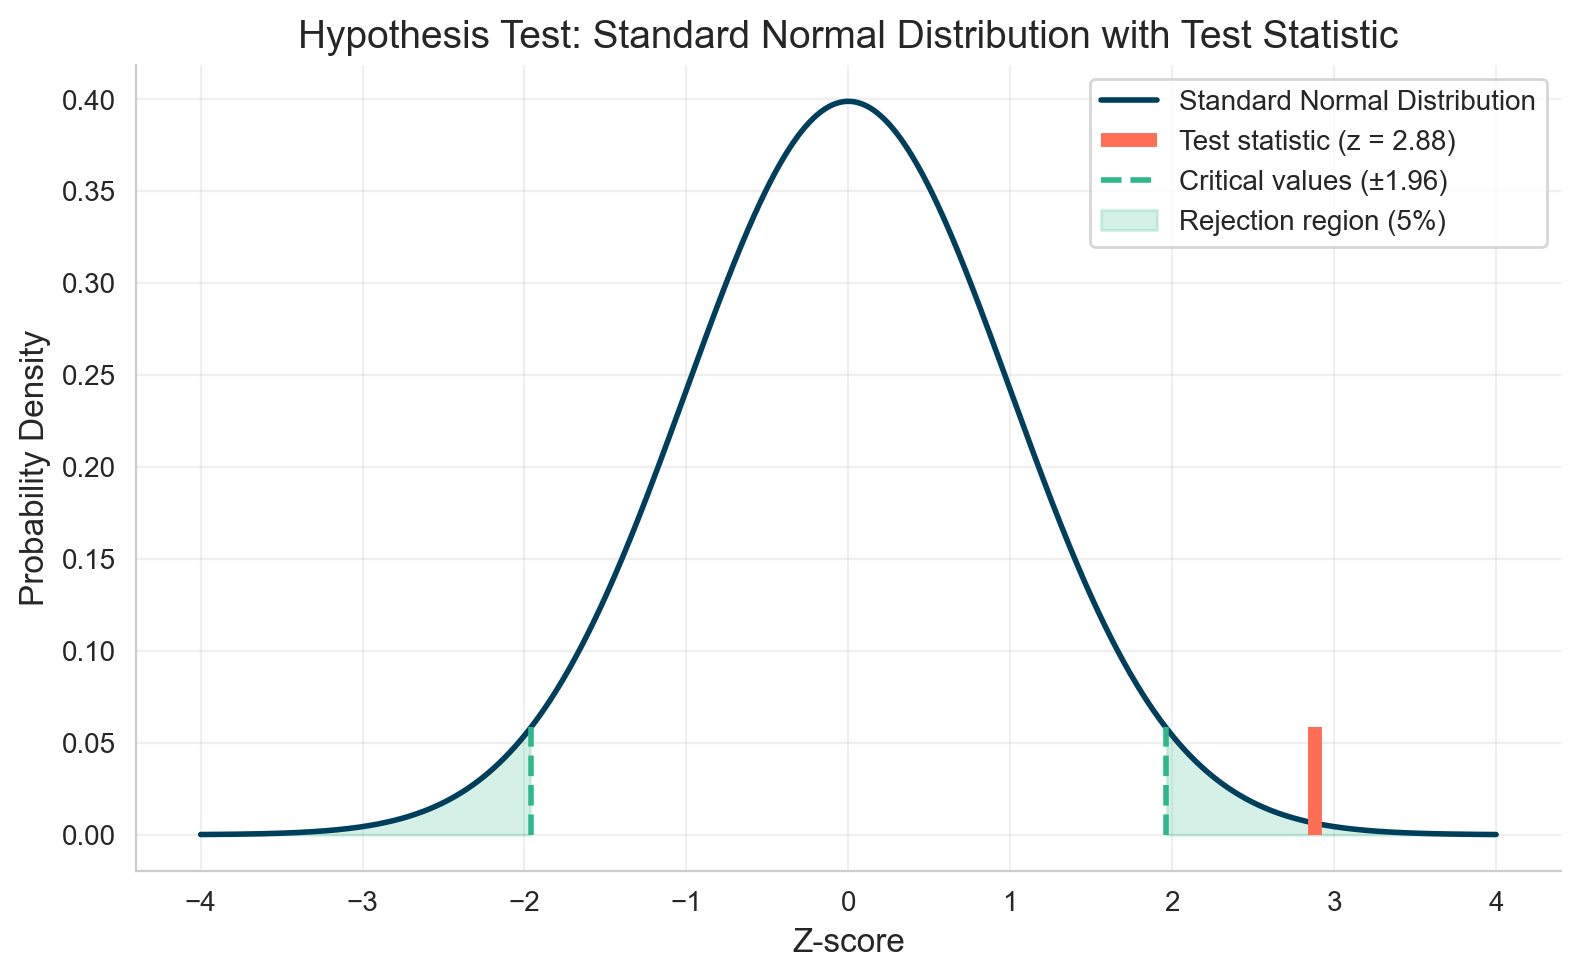

In [13]:
# Create x values for normal distribution curve
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)
alpha = 0.05
lower_critical = stats.norm.ppf(alpha / 2)  # 2.5th percentile
upper_critical = stats.norm.ppf(1 - alpha / 2)  # 97.5th percent
# Create the plot
plt.figure(figsize=(8, 5))
# Plot standard normal distribution curve
plt.plot(
    x,
    y,
    label="Standard Normal Distribution",
    color=high_contrast_colors[0],
    linewidth=2,
)
# Add test statistic vertical line
plt.vlines(
    t_statistic,
    ymin=0,
    # ymax=stats.norm.pdf(t_statistic, 0, 1),
    ymax=stats.norm.pdf(lower_critical, 0, 1),
    label=f"Test statistic (z = {t_statistic:.2f})",
    color=high_contrast_colors[1],
    linewidth=5,
)
# Plot critical values
plt.vlines(
    lower_critical,
    ymin=0,
    ymax=stats.norm.pdf(lower_critical, 0, 1),
    label="Critical values (±1.96)",
    color=high_contrast_colors[3],
    linewidth=2,
    linestyle="--",
)
plt.vlines(
    upper_critical,
    ymin=0,
    ymax=stats.norm.pdf(upper_critical, 0, 1),
    color=high_contrast_colors[3],
    linewidth=2,
    linestyle="--",
)
# Fill rejection regions
plt.fill_between(
    x[x <= lower_critical],
    0,
    stats.norm.pdf(x[x <= lower_critical], 0, 1),
    alpha=0.2,
    color=high_contrast_colors[3],
    label="Rejection region (5%)",
)
plt.fill_between(
    x[x >= upper_critical],
    0,
    stats.norm.pdf(x[x >= upper_critical], 0, 1),
    alpha=0.2,
    color=high_contrast_colors[3],
)
# Add labels and title
plt.title(
    "Hypothesis Test: Standard Normal Distribution with Test Statistic", fontsize=14
)
plt.xlabel("Z-score", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

For formality, we can calculate the **p-value** as follows and summarize our A/B test comparing the weights of **Wonderstan** and **No Ones Land**:

In [14]:
# Step 4: Make a decision about the null hypothesis
if t_statistic < 0:
    p_value = 2 * stats.norm.cdf(t_statistic)  # Left tail * 2
else:
    p_value = 2 * (1 - stats.norm.cdf(t_statistic))  # Right tail * 2


print(f"Mean Difference: {mean_difference:.2f}")
print(f"Standard Error of the Difference: {standard_error_of_difference:.2f}")
print(f"Test Statistic (z-score): {t_statistic:.4f}")
print(f"Critical Values (α = {alpha}): {lower_critical:.2f} and {upper_critical:.2f}")
print(f"P-value: {p_value:.4f}")
print("-" * 50)

# Determine if we reject the null hypothesis
if t_statistic < lower_critical or t_statistic > upper_critical:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference")
    print("            between weights of people of Wonderstan and No Ones Land.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence to conclude")
    print(
        "        a significant difference between weights of people of Wonderstan and No Ones Land."
    )

Mean Difference: 2.62
Standard Error of the Difference: 0.91
Test Statistic (z-score): 2.8838
Critical Values (α = 0.05): -1.96 and 1.96
P-value: 0.0039
--------------------------------------------------
Decision: Reject the null hypothesis.
Conclusion: There is a statistically significant difference
            between weights of people of Wonderstan and No Ones Land.


## Practical Example: Comparing Group Proportions

As mentioned earlier, comparing **proportions** differs slightly from comparing means. Let’s see how it works.

Suppose our dataset contains **heights** of people from both countries. We calculate **BMI** and classify individuals as:

* **Obese (1)**
* **Not obese (0)**

Our task is to determine whether there is a difference between the two countries in **obesity rates** — the proportion of obese individuals in the population.

Similar to the previous example, we can:

* Calculate the **obesity rate** for each country
* Compute **confidence intervals** around these proportions
* Check whether the intervals **overlap** to assess statistical significance.

In [15]:
np.random.seed(42)
heights_1 = np.random.normal(loc=165, scale=10, size=len(df_no_ones_land_single_sample))
heights_2 = np.random.normal(loc=175, scale=13, size=len(df_wonderstan_single_sample))
df_no_ones_land_single_sample["height"] = heights_1
df_wonderstan_single_sample["height"] = heights_2
df_ab_test = pd.concat(
    [df_no_ones_land_single_sample, df_wonderstan_single_sample], ignore_index=True
)
df_ab_test["bmi"] = df_ab_test["weight"] / (df_ab_test["height"] / 100) ** 2
df_ab_test["is_obese"] = df_ab_test["bmi"] >= 30
df_ab_test.head()

,person_id,weight,country,height,bmi,is_obese
0,person_1,70.679798,No Ones Land,169.967142,24.466135,False
1,person_2,71.778589,No Ones Land,163.617357,26.812430,False
2,person_3,85.799607,No Ones Land,171.476885,29.179250,False
3,person_4,84.839126,No Ones Land,180.230299,26.118040,False
4,person_5,65.453063,No Ones Land,162.658466,24.738686,False


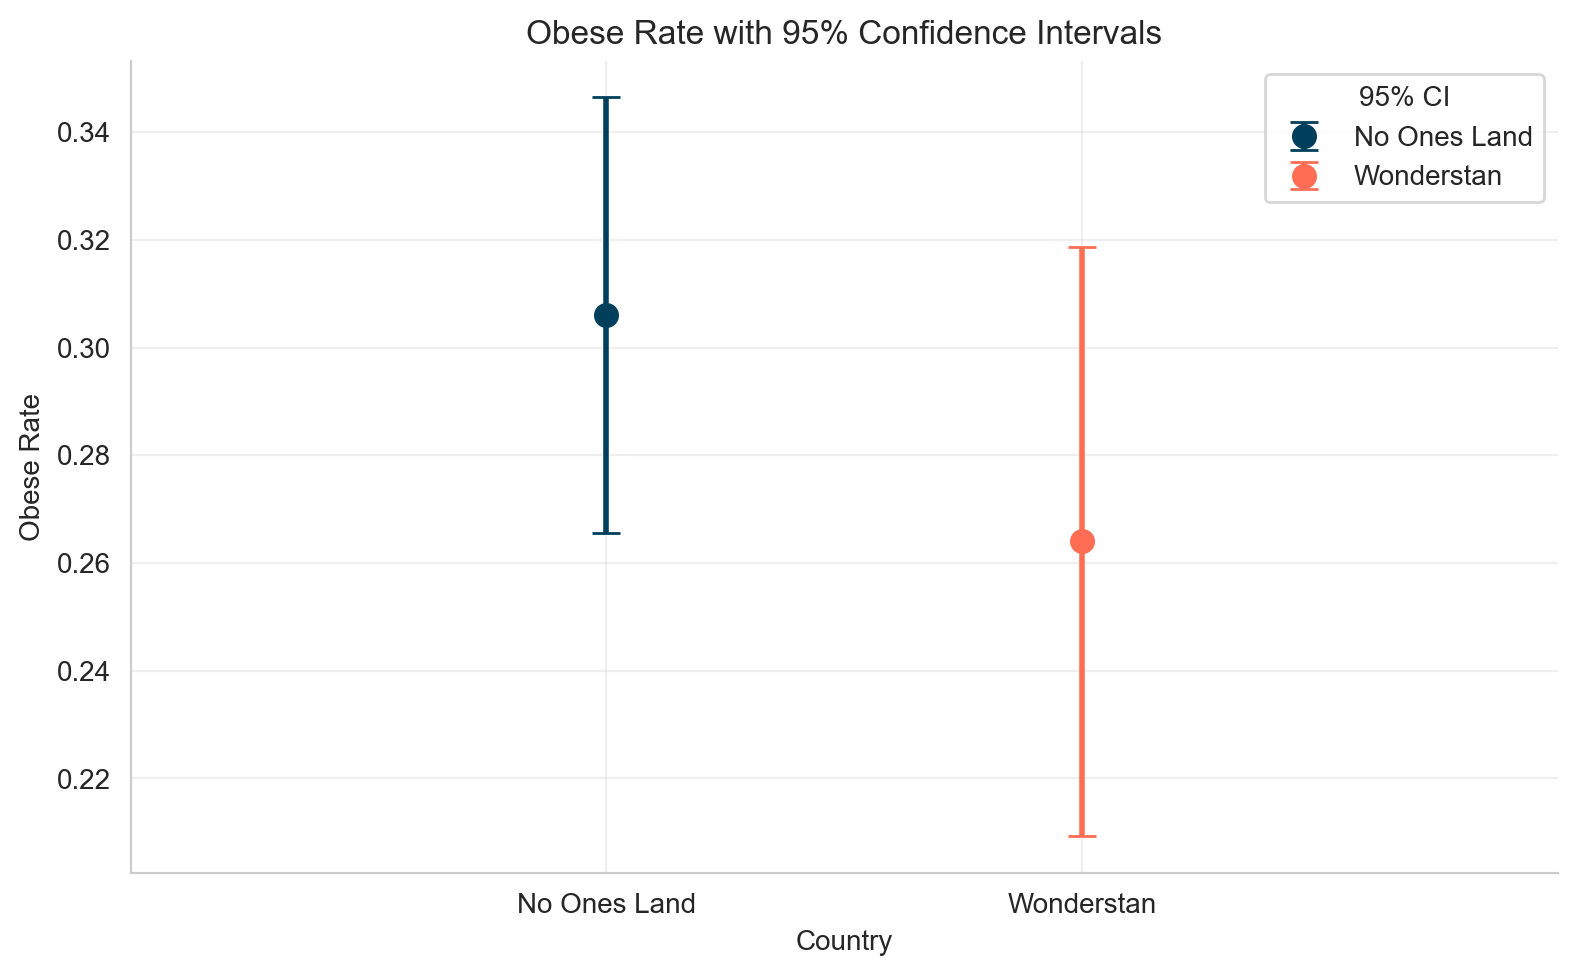

In [16]:
df_summary_stats = df_ab_test.groupby("country")["is_obese"].agg(
    ["mean", "sum", "count", "sem"]
)
df_summary_stats["ci_95_lower"] = (
    df_summary_stats["mean"] - 1.96 * df_summary_stats["sem"]
)
df_summary_stats["ci_95_upper"] = (
    df_summary_stats["mean"] + 1.96 * df_summary_stats["sem"]
)
df_summary_stats = df_summary_stats.reset_index()
fig = plt.figure(figsize=(8, 5))
for i, group in enumerate(df_summary_stats["country"]):
    plt.errorbar(
        group,
        df_summary_stats["mean"].iloc[i],
        yerr=np.array(
            [
                df_summary_stats["mean"].iloc[i]
                - df_summary_stats["ci_95_lower"].iloc[i],
                df_summary_stats["ci_95_upper"].iloc[i]
                - df_summary_stats["mean"].iloc[i],
            ]
        ).reshape(2, 1),
        fmt="o",
        linewidth=2,
        markersize=8,
        color=high_contrast_colors[i % len(high_contrast_colors)],
        capsize=5,
        label=group,
    )

# Customize plot appearance
plt.title("Obese Rate with 95% Confidence Intervals")
plt.xlabel("Country")
plt.ylabel("Obese Rate")
plt.grid(alpha=0.3)
plt.legend(title="95% CI")
# plt.ylim(70, 81)
plt.xlim(-1, 2)
sns.despine()
plt.tight_layout()
plt.show()

As we can see, the **confidence intervals overlap**, indicating that there is **no significant difference** between the countries’ obesity rates.

Similar to our comparison of means, we can calculate the **t test statistic (z-statistic for proportions)**, plot it on a standard normal distribution, and check whether it falls within the **95% critical values**. We can then formalize the result by computing the **p-value**.

**We will use following formula to calculate the test statistic:**

* **Pooled proportion:**

$$
p = \frac{x_1 + x_2}{n_1 + n_2}
$$

* **Test statistic:**

$$
z = \frac{p_1 - p_2}{\sqrt{p(1-p)\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}
$$


In [17]:
wonderstan_data_points = df_ab_test[df_ab_test["country"] == "Wonderstan"][
    "is_obese"
].values
no_ones_land_data_points = df_ab_test[df_ab_test["country"] == "No Ones Land"][
    "is_obese"
].values
mean_difference = wonderstan_data_points.mean() - no_ones_land_data_points.mean()
print(
    f"Mean Difference (Mean of Wonderstan - Mean of No Ones Land): {mean_difference:.2f}"
)
pooled_rate = (wonderstan_data_points.sum() + no_ones_land_data_points.sum()) / (
    len(wonderstan_data_points) + len(no_ones_land_data_points)
)
standard_error_of_difference = np.sqrt(
    pooled_rate
    * (1 - pooled_rate)
    * (1 / len(wonderstan_data_points) + 1 / len(no_ones_land_data_points))
)
print(f"Standard Error of the Difference: {standard_error_of_difference:.2f}")
t_statistic = mean_difference / standard_error_of_difference
print(f"T-Statistic: {t_statistic:.2f}")

Mean Difference (Mean of Wonderstan - Mean of No Ones Land): -0.04
Standard Error of the Difference: 0.04
T-Statistic: -1.19


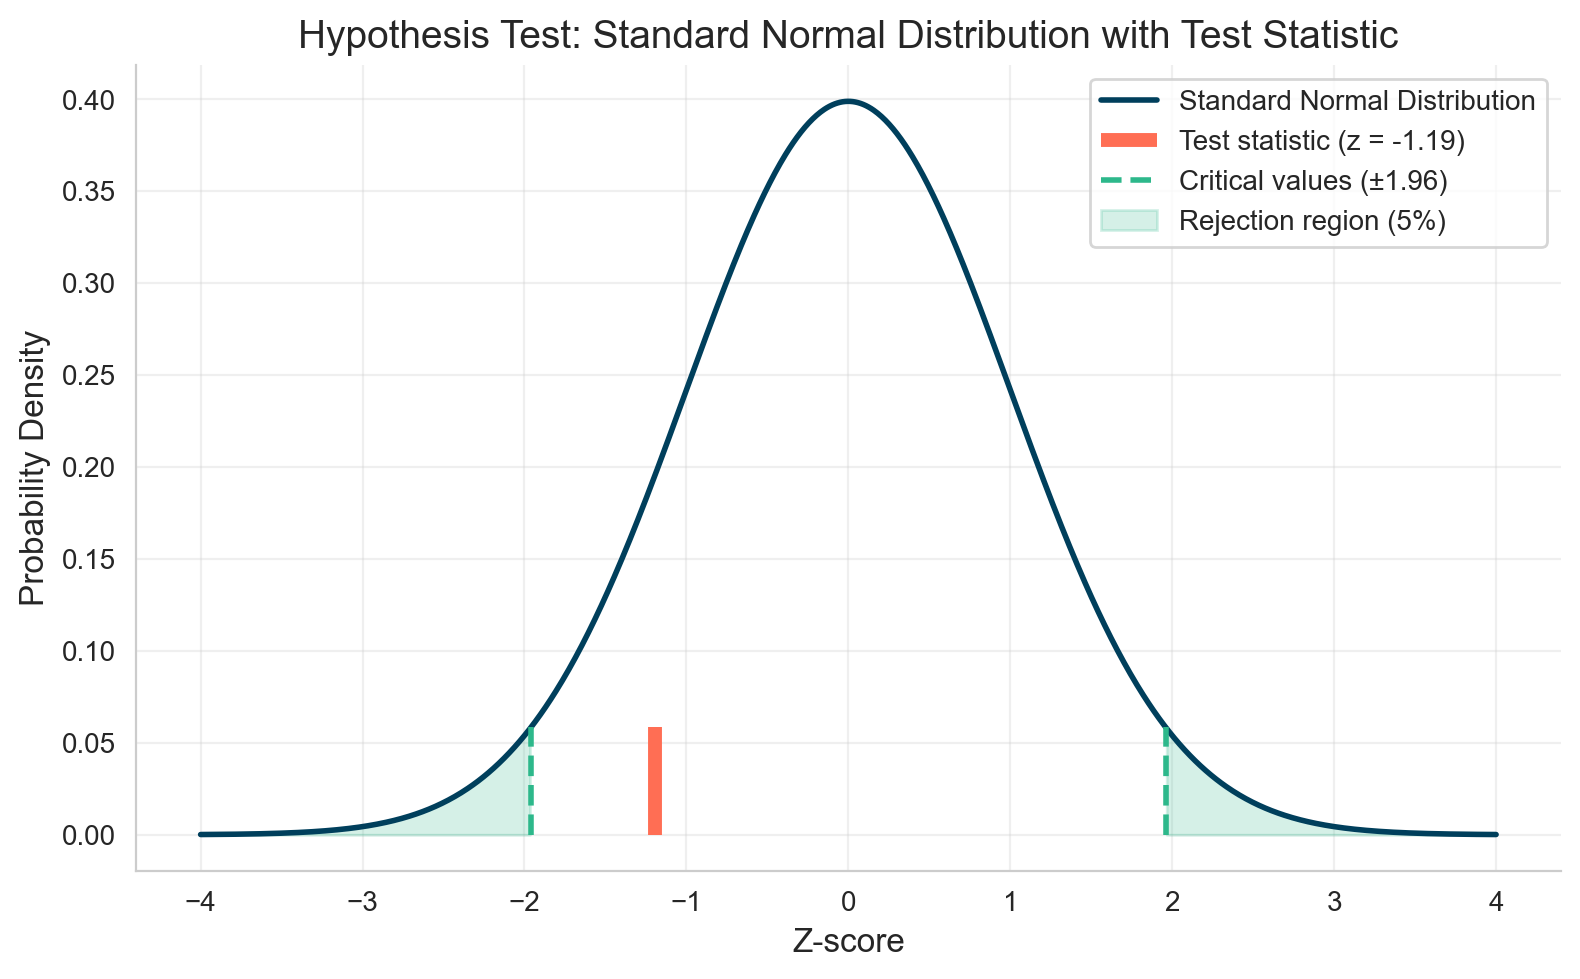

In [18]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)
alpha = 0.05
lower_critical = stats.norm.ppf(alpha / 2)  # 2.5th percentile
upper_critical = stats.norm.ppf(1 - alpha / 2)
# Create the plot
plt.figure(figsize=(8, 5))

# Plot standard normal distribution curve
plt.plot(
    x,
    y,
    label="Standard Normal Distribution",
    color=high_contrast_colors[0],
    linewidth=2,
)

# Add test statistic vertical line
plt.vlines(
    t_statistic,
    ymin=0,
    # ymax=stats.norm.pdf(t_statistic, 0, 1),
    ymax=stats.norm.pdf(lower_critical, 0, 1),
    label=f"Test statistic (z = {t_statistic:.2f})",
    color=high_contrast_colors[1],
    linewidth=5,
)


# Plot critical values
plt.vlines(
    lower_critical,
    ymin=0,
    ymax=stats.norm.pdf(lower_critical, 0, 1),
    label="Critical values (±1.96)",
    color=high_contrast_colors[3],
    linewidth=2,
    linestyle="--",
)

plt.vlines(
    upper_critical,
    ymin=0,
    ymax=stats.norm.pdf(upper_critical, 0, 1),
    color=high_contrast_colors[3],
    linewidth=2,
    linestyle="--",
)

# Fill rejection regions
plt.fill_between(
    x[x <= lower_critical],
    0,
    stats.norm.pdf(x[x <= lower_critical], 0, 1),
    alpha=0.2,
    color=high_contrast_colors[3],
    label="Rejection region (5%)",
)
plt.fill_between(
    x[x >= upper_critical],
    0,
    stats.norm.pdf(x[x >= upper_critical], 0, 1),
    alpha=0.2,
    color=high_contrast_colors[3],
)

# Add labels and title
plt.title(
    "Hypothesis Test: Standard Normal Distribution with Test Statistic", fontsize=14
)
plt.xlabel("Z-score", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
# Step 4: Make a decision about the null hypothesis
if t_statistic < 0:
    p_value = 2 * stats.norm.cdf(t_statistic)  # Left tail * 2
else:
    p_value = 2 * (1 - stats.norm.cdf(t_statistic))  # Right tail * 2


print(f"Mean Difference: {mean_difference:.4f}")
print(f"Standard Error of the Difference: {standard_error_of_difference:.4f}")
print(f"Test Statistic (z-score): {t_statistic:.4f}")
print(f"Critical Values (α = {alpha}): {lower_critical:.4f} and {upper_critical:.4f}")
print(f"P-value: {p_value:.8f}")
print("-" * 50)

# Determine if we reject the null hypothesis
if t_statistic < lower_critical or t_statistic > upper_critical:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference")
    print("            between obesity rates of people of Wonderstan and No Ones Land.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is insufficient evidence to conclude")
    print(
        "        a significant difference between obesity rates of people of Wonderstan and No Ones Land."
    )

Mean Difference: -0.0420
Standard Error of the Difference: 0.0352
Test Statistic (z-score): -1.1925
Critical Values (α = 0.05): -1.9600 and 1.9600
P-value: 0.23305748
--------------------------------------------------
Decision: Fail to reject the null hypothesis.
Conclusion: There is insufficient evidence to conclude
        a significant difference between obesity rates of people of Wonderstan and No Ones Land.


## One-Liners: A/B Testing in Python
For clarity, we calculated all the values manually using the formulas above to see how A/B testing works. However, we **don’t need to reinvent the wheel** — several statistical libraries can perform A/B tests in a single line of code.

We can use the following packages to quickly test **means** and **proportions** as we did above:

```python
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
```


In [20]:
wonderstan_data_points = df_ab_test[df_ab_test["country"] == "Wonderstan"][
    "weight"
].values
no_ones_land_data_points = df_ab_test[df_ab_test["country"] == "No Ones Land"][
    "weight"
].values
# Perform an independent samples t-test using scipy
result = stats.ttest_ind(
    no_ones_land_data_points, wonderstan_data_points, equal_var=False
)  # Welch's t-test (doesn't assume equal variances)

# Display the comprehensive results
print("Independent Samples T-Test Results:")
print("-" * 50)
print(f"T-statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.8f}")
print("-" * 50)

# Interpret results
alpha = 0.05
if result.pvalue < alpha:
    print(
        f"Decision: Reject the null hypothesis (p = {result.pvalue:.8f} < α = {alpha})"
    )
else:
    print(
        f"Decision: Fail to reject the null hypothesis (p = {result.pvalue:.8f} ≥ α = {alpha})"
    )

Independent Samples T-Test Results:
--------------------------------------------------
T-statistic: -2.8787
P-value: 0.00420329
--------------------------------------------------
Decision: Reject the null hypothesis (p = 0.00420329 < α = 0.05)


In [21]:
wonderstan_data_points = df_ab_test[df_ab_test["country"] == "Wonderstan"][
    "is_obese"
].values
no_ones_land_data_points = df_ab_test[df_ab_test["country"] == "No Ones Land"][
    "is_obese"
].values
zscore_, pvalue = proportions_ztest(
    [wonderstan_data_points.sum(), no_ones_land_data_points.sum()],
    [len(wonderstan_data_points), len(no_ones_land_data_points)],
)

# Display the comprehensive results
print("Samples Proportions Z-Test Results:")
print("-" * 50)
print(f"T-statistic: {zscore_:.4f}")
print(f"P-value: {pvalue:.8f}")
print("-" * 50)

if pvalue < 0.05:
    print(f"Decision: Reject the null hypothesis (p = {pvalue:.8f} < α = 0.05).")
else:
    print(
        f"Decision: Fail to reject the null hypothesis (p = {pvalue:.8f} ≥ α = 0.05)."
    )

Samples Proportions Z-Test Results:
--------------------------------------------------
T-statistic: -1.1925
P-value: 0.23305748
--------------------------------------------------
Decision: Fail to reject the null hypothesis (p = 0.23305748 ≥ α = 0.05).
